# AICE 모의고사 4회 - 기후 변화 예측

## 문제 시나리오

과거 기상 정보 및 환경 데이터를 분석 및 전처리한 후 머신러닝과 딥러닝으로 특정 지역의 연간 평균 기온을 변화를 예측하고 결과를 분석하세요.

---

## 4-1 | 라이브러리 임포트 및 데이터 로딩

### 【 문제 】

- 필요한 패키지를 임포트 pandas 라이브러리를 pd라는 별칭으로 임포트하고, 두 개의 데이터를 분석에 활용하는 코드를 작성하세요.
- climate_data.json 파일을 읽어 데이터프레임 변수 df_climate에 할당하세요.
- pollution_data.csv 파일을 읽어 데이터프레임 변수 df_pollution에 할당하세요.

In [57]:
import pandas as pd

In [58]:
df_climate = pd.read_json('C:/juehyeon/aice_test/기출문제/4.기후변화예측/climate_data.json')

In [59]:
df_pollution = pd.read_csv('C:/juehyeon/aice_test/기출문제/4.기후변화예측/pollution_data.csv')

## 4-2 | 데이터 병합 및 초기 탐색

### 【 문제 】

- 두 개의 데이터프레임(df_climate, df_pollution)을 LocationID와 Year 컬럼을 기준으로 병합하고, 병합된 데이터프레임의 상위 5개 행과 컬럼별 요약 정보를 출력하여 초기 데이터를 탐색하는 코드를 작성하세요.
- pandas의 merge 함수를 사용하여 df_climate와 df_pollution을 LocationID와 Year를 키(key)로 병합하고 df 변수에 저장하세요.
- 병합 방식은 inner로 지정하세요.
- df 데이터프레임의 상위 5개 행을 출력하세요.
- df 데이터프레임의 컬럼별 정보(dtype, Non-null Count)를 확인하세요.


In [60]:
df = pd.merge(df_climate, df_pollution, on = ['LocationID','Year'], how = 'inner')

In [61]:
df.head()

,LocationID,Year,AvgTemperature_C,CO2_Concentration_ppm,SeaLevel_mm,ForestArea_percent,UrbanArea_percent,MajorEvent,PM25_ug_m3,Ozone_ppb,IndustrialEmissions_tons
0,16,2012,15.43,592,2.7,58.4,32.3,Flood,63.7,65.4,1488
1,8,2021,27.74,450,3.4,53.2,37.5,Flood,52.8,69.1,8099
2,17,2016,29.53,403,1.6,30.5,33.5,Storm,38.3,21.2,45298
3,5,2019,29.67,446,1.8,37.9,36.3,Storm,74.5,63.2,33376
4,5,2019,29.67,446,1.8,37.9,36.3,Storm,20.6,94.4,13329


In [62]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 41 entries, 0 to 40
Data columns (total 11 columns):
 #   Column                    Non-Null Count  Dtype  
---  ------                    --------------  -----  
 0   LocationID                41 non-null     int64  
 1   Year                      41 non-null     int64  
 2   AvgTemperature_C          41 non-null     float64
 3   CO2_Concentration_ppm     41 non-null     int64  
 4   SeaLevel_mm               40 non-null     float64
 5   ForestArea_percent        41 non-null     float64
 6   UrbanArea_percent         41 non-null     float64
 7   MajorEvent                41 non-null     object 
 8   PM25_ug_m3                41 non-null     float64
 9   Ozone_ppb                 41 non-null     float64
 10  IndustrialEmissions_tons  41 non-null     int64  
dtypes: float64(6), int64(4), object(1)
memory usage: 3.7+ KB



## 4-3 | 범주형 변수 로트 시각화 및 데이터 경제

### 【 문제 】

- MajorEvent 컬럼의 분포를 시각화하고, 데이터 경제를 위해 'Unknown' 값을 가진 행을 제거하는 코드를 작성하세요.
- seaborn 라이브러리의 countplot을 사용하여 MajorEvent 컬럼의 분포를 시각화하세요.
- MajorEvent 컬럼 값이 'Unknown'인 행을 데이터프레임에서 삭제하세요.

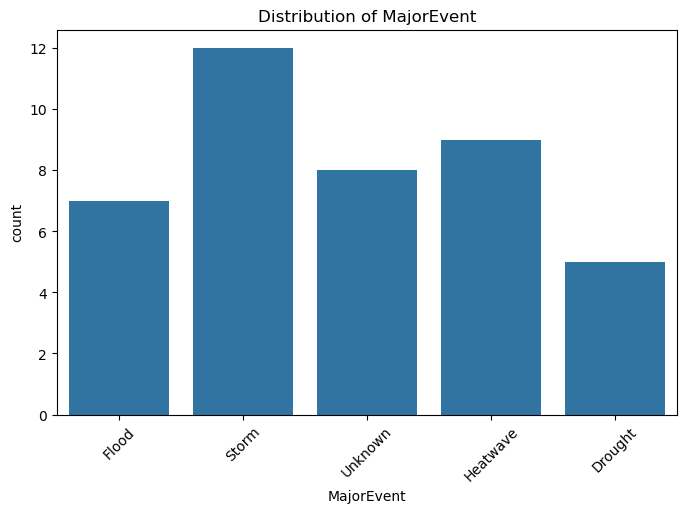

In [63]:
import seaborn as sns
import matplotlib.pyplot as plt

plt.figure(figsize=(8, 5))
sns.countplot(data=df, x='MajorEvent')
plt.title('Distribution of MajorEvent')
plt.xticks(rotation=45)
plt.show()

In [64]:
df = df[df['MajorEvent'] != 'Unknown']

<Axes: xlabel='MajorEvent', ylabel='count'>

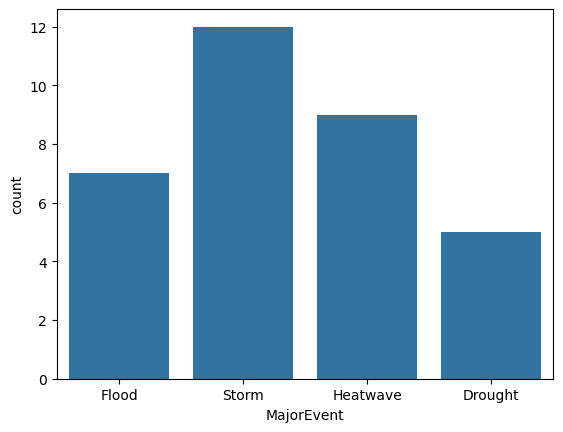

In [65]:
sns.countplot(data=df, x='MajorEvent')


## 4-4 | 수치형 변수 관계 시각화 및 이상치 탐색

### 【 문제 】

- CO2_Concentration_ppm과 AvgTemperature_C 간의 관계를 jointplot으로 시각화하고, CO2_Concentration_ppm가 500 이상인 이상치를 찾아 행의 개수를 확인하는 코드를 작성하세요.
- seaborn 라이브러리의 jointplot을 사용하여 x축에 CO2_Concentration_ppm, y축에 AvgTemperature_C를 표시하세요.
- CO2_Concentration_ppm가 500 이상인 행의 개수를 세어 출력하세요.

In [66]:
df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 33 entries, 0 to 40
Data columns (total 11 columns):
 #   Column                    Non-Null Count  Dtype  
---  ------                    --------------  -----  
 0   LocationID                33 non-null     int64  
 1   Year                      33 non-null     int64  
 2   AvgTemperature_C          33 non-null     float64
 3   CO2_Concentration_ppm     33 non-null     int64  
 4   SeaLevel_mm               33 non-null     float64
 5   ForestArea_percent        33 non-null     float64
 6   UrbanArea_percent         33 non-null     float64
 7   MajorEvent                33 non-null     object 
 8   PM25_ug_m3                33 non-null     float64
 9   Ozone_ppb                 33 non-null     float64
 10  IndustrialEmissions_tons  33 non-null     int64  
dtypes: float64(6), int64(4), object(1)
memory usage: 3.1+ KB


<Figure size 800x500 with 0 Axes>

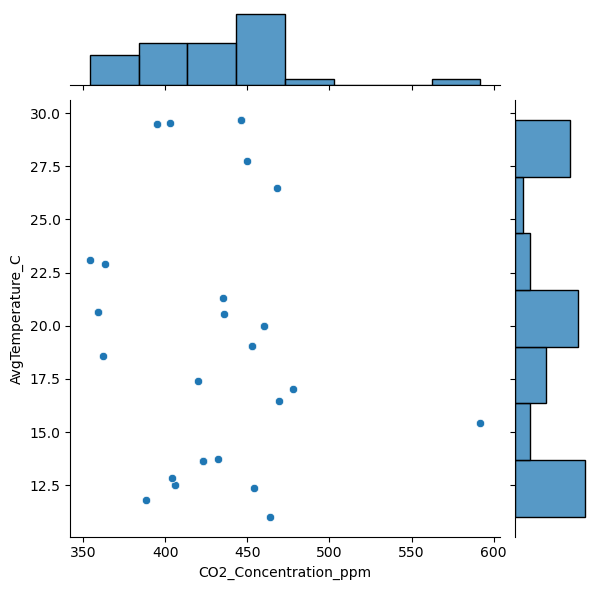

In [67]:
plt.figure(figsize = (8, 5))
sns.jointplot(
    data = df,
    x = 'CO2_Concentration_ppm', 
    y = 'AvgTemperature_C'
)
plt.xlabel = 'CO2_Concentration_ppm'
plt.ylabel = 'AvgTemperature_C'
plt.show()

In [68]:
row_count = df[df['CO2_Concentration_ppm'] >= 500].shape[0]

In [69]:
row_count

1

## 4-5 | 이상치 및 불필요 컬럼 처리

### 【 문제 】

- CO2_Concentration_ppm가 500 이상인 이상치 행을 삭제하고, 모델링에 불필요한 LocationID와 Year 컬럼을 삭제하는 코드를 작성하세요.
- CO2_Concentration_ppm가 500 미만인 행만 남기고 데이터프레임을 업데이트하세요.
- LocationID와 Year 컬럼을 데이터프레임에서 삭제하세요.
- 변경된 데이터프레임을 df_cleaned에 저장하세요.

In [74]:
df_cleaned = df[df['CO2_Concentration_ppm'] < 500].copy()

In [76]:
df_cleaned = df_cleaned.drop(columns = ['LocationID', 'Year'])

In [77]:
df_cleaned.info()

<class 'pandas.core.frame.DataFrame'>
Index: 32 entries, 1 to 40
Data columns (total 9 columns):
 #   Column                    Non-Null Count  Dtype  
---  ------                    --------------  -----  
 0   AvgTemperature_C          32 non-null     float64
 1   CO2_Concentration_ppm     32 non-null     int64  
 2   SeaLevel_mm               32 non-null     float64
 3   ForestArea_percent        32 non-null     float64
 4   UrbanArea_percent         32 non-null     float64
 5   MajorEvent                32 non-null     object 
 6   PM25_ug_m3                32 non-null     float64
 7   Ozone_ppb                 32 non-null     float64
 8   IndustrialEmissions_tons  32 non-null     int64  
dtypes: float64(6), int64(2), object(1)
memory usage: 2.5+ KB



## 4-6 | 결측치 처리 및 데이터 타입 변환

### 【 문제 】

- 데이터프레임에 결측치가 있는지 확인하고, 결측치가 있는 행을 삭제한 뒤, SeaLevel_mm 컬럼을 정수형(int)으로 변환하세요.
- df_cleaned의 결측치를 확인하는 코드를 작성하세요.

In [82]:
df_cleaned.isna().sum()

AvgTemperature_C            0
CO2_Concentration_ppm       0
SeaLevel_mm                 0
ForestArea_percent          0
UrbanArea_percent           0
MajorEvent                  0
PM25_ug_m3                  0
Ozone_ppb                   0
IndustrialEmissions_tons    0
dtype: int64

In [85]:
df_cleaned['SeaLevel_mm'] = df_cleaned['SeaLevel_mm'].astype(int)

In [88]:
df_cleaned.info()

<class 'pandas.core.frame.DataFrame'>
Index: 32 entries, 1 to 40
Data columns (total 9 columns):
 #   Column                    Non-Null Count  Dtype  
---  ------                    --------------  -----  
 0   AvgTemperature_C          32 non-null     float64
 1   CO2_Concentration_ppm     32 non-null     int64  
 2   SeaLevel_mm               32 non-null     int64  
 3   ForestArea_percent        32 non-null     float64
 4   UrbanArea_percent         32 non-null     float64
 5   MajorEvent                32 non-null     object 
 6   PM25_ug_m3                32 non-null     float64
 7   Ozone_ppb                 32 non-null     float64
 8   IndustrialEmissions_tons  32 non-null     int64  
dtypes: float64(5), int64(3), object(1)
memory usage: 2.5+ KB


## 4-7 | 불필요 컬럼 처리 및 범주형 변수 원-핫 인코딩

### 【 문제 】

- UrbanArea_percent 컬럼을 삭제하고, object 타입의 범주형 컬럼(MajorEvent)을 원-핫 인코딩하세요.
- df_cleaned에서 UrbanArea_percent 컬럼을 삭제하세요.
- pandas의 get_dummies 함수를 활용하여 object 타입의 컬럼에 대해 원-핫 인코딩을 수행하세요.
- 변경된 결과를 df_encoded 변수에 저장하세요.

In [103]:
df_encoded = df_cleaned.drop(columns = 'UrbanArea_percent').copy()

In [104]:
df_encoded = pd.get_dummies(df, columns=['MajorEvent'])

In [105]:
df_encoded.head()

,LocationID,Year,AvgTemperature_C,CO2_Concentration_ppm,SeaLevel_mm,ForestArea_percent,UrbanArea_percent,PM25_ug_m3,Ozone_ppb,IndustrialEmissions_tons,MajorEvent_Drought,MajorEvent_Flood,MajorEvent_Heatwave,MajorEvent_Storm
0,16,2012,15.43,592,2.7,58.4,32.3,63.7,65.4,1488,False,True,False,False
1,8,2021,27.74,450,3.4,53.2,37.5,52.8,69.1,8099,False,True,False,False
2,17,2016,29.53,403,1.6,30.5,33.5,38.3,21.2,45298,False,False,False,True
3,5,2019,29.67,446,1.8,37.9,36.3,74.5,63.2,33376,False,False,False,True
4,5,2019,29.67,446,1.8,37.9,36.3,20.6,94.4,13329,False,False,False,True



## 4-8 | 데이터 분리 및 스케일링

### 【 문제 】

- 최종 기온(AvgTemperature_C)을 예측하기 위해 데이터를 훈련 및 검증 데이터로 분리하고, 스케일링을 수행하세요.
- AvgTemperature_C 컬럼을 y 변수에, 나머지 컬럼을 X 변수에 할당하세요.
- scikit-learn의 train_test_split 함수를 사용하여 X와 y를 훈련 데이터(80%)와 검증 데이터(20%)으로 분리하세요. random_state는 42로 설정하세요.
- sklearn.preprocessing의 StandardScaler를 사용하여 훈련 데이터와의 Feature(X_train)를 스케일링하고 X_train_scaled에 할당하세요.
- StandardScaler의 transform 함수를 사용하여 검증 데이터와의 Feature(X_valid)를 스케일링하고 X_valid_scaled에 할당하세요.

In [106]:
from sklearn.model_selection import train_test_split